In [8]:
# Install unrar to handle .rar files
!apt-get install unrar

# Download the public dataset using the file ID from your link
!gdown 1JbN0Xdk7QtIu2i9U3NWchEqav0oInBOZ -O test_dataset.rar

# Extract the dataset into a folder named /content/test_dataset
!mkdir -p test_dataset
!unrar x test_dataset.rar /content/test_dataset/

Streaming output truncated to the last 5000 lines.
Extracting  /content/test_dataset/test_dataset/test_dark_blur/labels/phone_dataset_6a3aeda3455c37a4_jpg.rf.dcc5e41ed9563f9cbbbecc04c7666d7f.txt      77%  OK 
Extracting  /content/test_dataset/test_dataset/test_dark_blur/labels/phone_dataset_6e6b69c33a686820_jpg.rf.e955152f7a40192acfcf3c0373cb67c7.txt      77%  OK 
Extracting  /content/test_dataset/test_dataset/test_dark_blur/labels/phone_dataset_6f3c487ba07141ba_jpg.rf.db9656cab9b5ce4ba69c29bdf5c3db34.txt      77%  OK 
Extracting  /content/test_dataset/test_dataset/test_dark_blur/labels/phone_dataset_701f228e7772487f_jpg.rf.7ec7fe83be95ab8dc226659b91bd3753_aug4109_rot+5.txt      77%  OK 
Extracting  /content/test_dataset/test_dataset/test_dark_blur/labels/phone_dataset_718aa111b6abc71a_jpg.rf.a9dd0282964723528887703f2e090feb.txt      77%  OK 
Extracting  /content/test_dataset/test_dataset/test_dark_blur/labels/phone_dataset_721264af3c25e01c_

In [9]:
# Install the Ultralytics library
%pip install ultralytics

# (Optional) Verify the installation and hardware
import ultralytics
ultralytics.checks()

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.4/112.6 GB disk)


In [10]:
import os
import pandas as pd
from ultralytics import YOLO

# --- CONFIGURATION ---
# Replace with the path to your uploaded best.pt weights
DATASET_ROOT = '/content/test_dataset/test_dataset'
MODEL_PATH = '/content/test_dataset/test_dataset/weights_11n/best.pt'

# List of folders as identified in your screenshot
TEST_FOLDERS = [
    "test", "test_occ", "test_blur2.0", "test_blur2.5",
    "test_bright", "test_bright_blur", "test_bright_triple_threat",
    "test_brightness_occlusion", "test_dark", "test_dark_blur",
    "test_dark_occlusion", "test_dark_triple_threat"
]

def create_temp_yaml(folder_name):
    """Creates a temporary YAML with mandatory keys for YOLO evaluation."""
    # Use the specific subdirectory path
    abs_path = os.path.join(DATASET_ROOT, folder_name)

    yaml_content = f"""
path: '{abs_path}' # Dataset root
train: images      # Mandatory key
val: images        # Mandatory key
test: images       # The folder you are actually testing
names:
  0: Phone
  1: Calculator
  2: Book
"""
    temp_yaml = f"temp_{folder_name}.yaml"
    with open(temp_yaml, 'w') as f:
        f.write(yaml_content)
    return temp_yaml

def run_benchmark():
    model = YOLO(MODEL_PATH)
    all_results = []  # <--- Ensure this is initialized at the start

    for folder in TEST_FOLDERS:
        print(f"\n📊 Evaluating: {folder}")
        temp_yaml = create_temp_yaml(folder)

        results = model.val(data=temp_yaml, split='test', imgsz=640, plots=True, name=f"bench_{folder}")

        # The variable name here must match the one initialized above
        all_results.append({
            "Scenario": folder,
            "mAP50": round(results.box.map50, 4),
            "mAP50-95": round(results.box.map, 4),
            "Precision": round(results.box.mp, 4),
            "Recall": round(results.box.mr, 4)
        })

    # Save summary table using the same name
    df = pd.DataFrame(all_results)
    df.to_csv("thesis_final_results.csv", index=False)
    print("\n" + "="*60 + "\n✅ MASTER BENCHMARK COMPLETE\n" + "="*60)
    print(df.to_string(index=False))

run_benchmark()


📊 Evaluating: test
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1890.3±650.6 MB/s, size: 51.5 KB)
val: Scanning /content/test_dataset/test_dataset/test/labels.cache... 807 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 807/807 241.8Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 22, len(boxes) = 960. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 4.3it/s 11.8s
                   all        807        960      0.953      0.908      0.946      0.752
                 Phone        269        339      0.941      0.844      0.913      0.722
   

Graph saved locally as: /content/yolo11n_performance_results.png


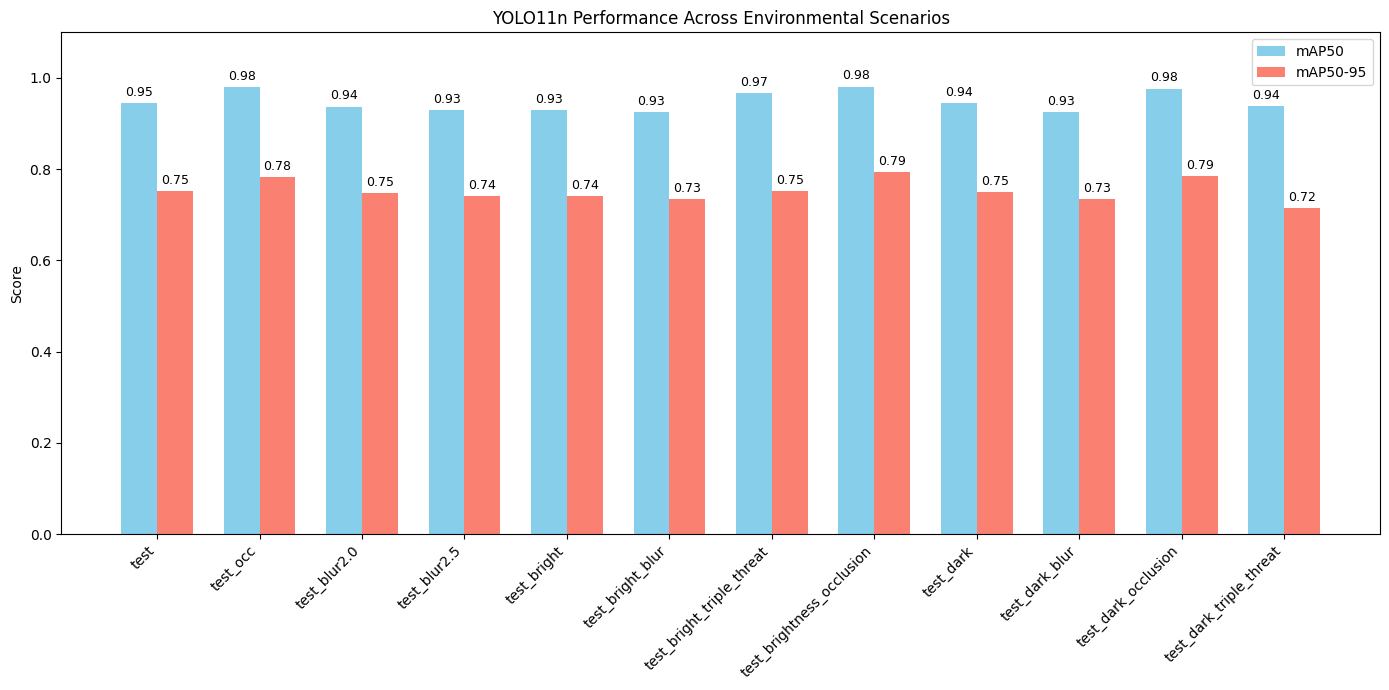

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Load your results
# df = pd.DataFrame(all_results)
df = pd.read_csv("thesis_final_results.csv")

# Set up the plot
scenarios = df['Scenario']
map50 = df['mAP50']
map50_95 = df['mAP50-95']

x = np.arange(len(scenarios))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - width/2, map50, width, label='mAP50', color='skyblue')
rects2 = ax.bar(x + width/2, map50_95, width, label='mAP50-95', color='salmon')

# Add labels and formatting
ax.set_ylabel('Score')
ax.set_title('YOLO11n Performance Across Environmental Scenarios')
ax.set_xticks(x)
ax.set_xticklabels(scenarios, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

# --- NEW: SAVE AND DOWNLOAD SECTION ---

# 1. Save the figure locally
filename = "yolo11n_performance_results.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Graph saved locally as: {os.path.abspath(filename)}")

# 2. Show the plot
plt.show()

# 3. If using Google Colab, trigger browser download
try:
    from google.colab import files
    files.download(filename)
except ImportError:
    # Not in Colab, skip browser download trigger
    pass

Graph saved as: /content/final_performance_trend_labeled.png


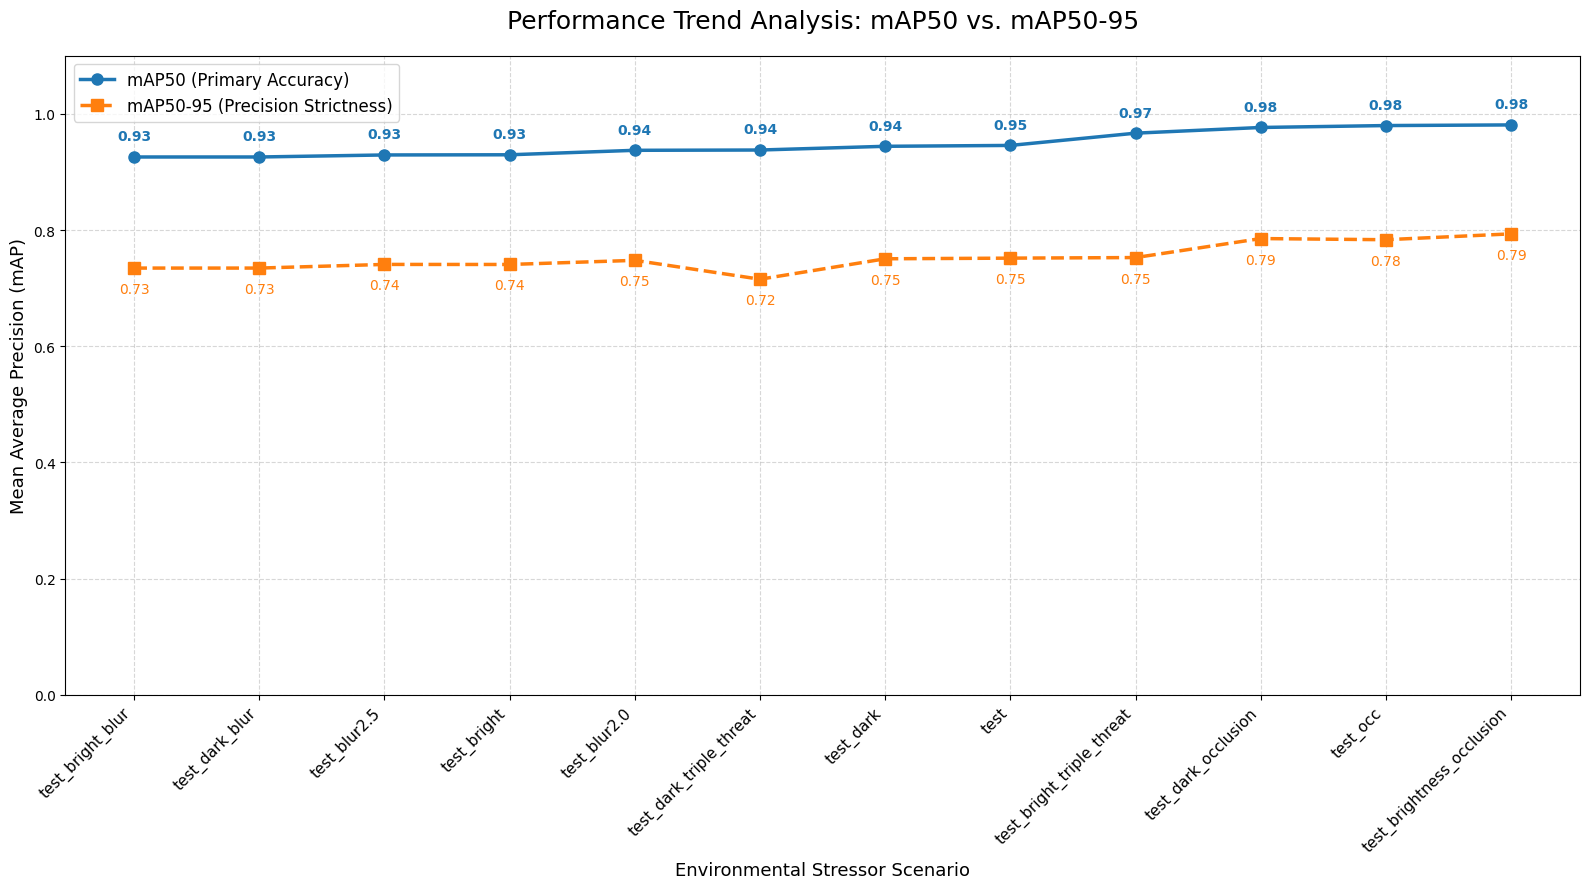

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# 1. Load and sort the results
df = pd.read_csv("thesis_final_results.csv")
df_sorted = df.sort_values(by='mAP50', ascending=True).reset_index(drop=True)

# 2. Initialize the Plot
plt.figure(figsize=(16, 9))

# Plot mAP50 (Blue Line)
plt.plot(df_sorted['Scenario'], df_sorted['mAP50'],
         marker='o', markersize=8, linestyle='-', linewidth=2.5,
         label='mAP50 (Primary Accuracy)', color='#1f77b4')

# Plot mAP50-95 (Orange Line)
plt.plot(df_sorted['Scenario'], df_sorted['mAP50-95'],
         marker='s', markersize=8, linestyle='--', linewidth=2.5,
         label='mAP50-95 (Precision Strictness)', color='#ff7f0e')

# 3. Add Labels to EVERY point
for i in range(len(df_sorted)):
    # Label for Blue Line (placed ABOVE the point)
    plt.annotate(f"{df_sorted['mAP50'][i]:.2f}",
                 (df_sorted['Scenario'][i], df_sorted['mAP50'][i]),
                 textcoords="offset points", xytext=(0, 12),
                 ha='center', fontsize=10, color='#1f77b4', fontweight='bold')

    # Label for Orange Line (placed BELOW the point to avoid overlap)
    plt.annotate(f"{df_sorted['mAP50-95'][i]:.2f}",
                 (df_sorted['Scenario'][i], df_sorted['mAP50-95'][i]),
                 textcoords="offset points", xytext=(0, -18),
                 ha='center', fontsize=10, color='#ff7f0e')

# 4. Final Formatting
plt.title('Performance Trend Analysis: mAP50 vs. mAP50-95', fontsize=18, pad=20)
plt.xlabel('Environmental Stressor Scenario', fontsize=13)
plt.ylabel('Mean Average Precision (mAP)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.ylim(0, 1.1)
plt.legend(fontsize=12, loc='upper left')

plt.tight_layout()

# --- SAVE AND DOWNLOAD LOGIC ---
filename = "final_performance_trend_labeled.png"

# Save locally at 300 DPI for high quality
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Graph saved as: {os.path.abspath(filename)}")

# Display the plot in the console/notebook
plt.show()

# Trigger browser download if using Google Colab
try:
    from google.colab import files
    files.download(filename)
except ImportError:
    pass

In [13]:
import pandas as pd
import os

# 1. Load the results
input_file = "thesis_final_results.csv"
df = pd.read_csv(input_file)

# 2. Sort the data (matching your trend analysis)
# This ensures the best-performing scenarios are highlighted
df_sorted = df.sort_values(by='mAP50', ascending=False).reset_index(drop=True)

# 3. Define the Excel filename
excel_filename = "YOLO11_Thesis_Results.xlsx"

# 4. Export to Excel
# We use the 'openpyxl' engine to create a standard .xlsx file
df_sorted.to_excel(excel_filename, index=False, sheet_name='Environmental_Scenarios')

print(f"Excel file successfully created: {os.path.abspath(excel_filename)}")

# 5. Trigger browser download if using Google Colab
try:
    from google.colab import files
    files.download(excel_filename)
    print("Download triggered in browser.")
except ImportError:
    print("Running locally: Your file is in the script folder.")

Excel file successfully created: /content/YOLO11_Thesis_Results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered in browser.


In [15]:
import os
import glob
import random
import shutil
import cv2
import torch
import pandas as pd
from ultralytics import YOLO
from google.colab import files

# --- CONFIGURATION ---
DATASET_ROOT = '/content/test_dataset/test_dataset'
MODEL_PATH = '/content/test_dataset/test_dataset/weights_11n/best.pt'

TEST_FOLDERS = [
    "test", "test_occ", "test_blur2.0", "test_blur2.5",
    "test_bright", "test_bright_blur", "test_bright_triple_threat",
    "test_brightness_occlusion", "test_dark", "test_dark_blur",
    "test_dark_occlusion", "test_dark_triple_threat"
]

# --- HELPER: IoU Calculation ---
# --- HELPER: IoU Calculation ---
def bbox_iou(box1, box2):
    """
    Calculate Intersection over Union (IoU).
    """
    x1, y1, w1, h1 = box1[:4]
    x2, y2, w2, h2 = box2[:4]

    b1_x1, b1_x2 = x1 - w1 / 2, x1 + w1 / 2
    b1_y1, b1_y2 = y1 - h1 / 2, y1 + h1 / 2
    b2_x1, b2_x2 = x2 - w2 / 2, x2 + w2 / 2
    b2_y1, b2_y2 = y2 - h2 / 2, y2 + h2 / 2

    inter_x1 = max(b1_x1, b2_x1)
    inter_y1 = max(b1_y1, b2_y1)
    inter_x2 = min(b1_x2, b2_x2)
    inter_y2 = min(b1_y2, b2_y2)

    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)

    # CORRECTED MATH BELOW
    b1_area = (b1_x2 - b1_x1) * (b1_y2 - b1_y1)
    b2_area = (b2_x2 - b2_x1) * (b2_y2 - b2_y1) # Calculate box 2 area
    union_area = b1_area + b2_area - inter_area # Calculate total union

    return inter_area / union_area if union_area > 0 else 0

# --- FALSE POSITIVE HUNTER & ZIPPER ---
def hunt_and_zip_misclassifications(model, target_count=16):
    print("\n🔍 Hunting for Misclassifications to ZIP...")

    # 1. Setup output folder
    output_dir = 'misclassified_samples'
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir) # Clean previous runs
    os.makedirs(output_dir)

    all_images = []
    for folder in TEST_FOLDERS:
        all_images.extend(glob.glob(os.path.join(DATASET_ROOT, folder, 'images', '*')))

    random.shuffle(all_images)
    saved_count = 0

    for img_path in all_images:
        if saved_count >= target_count:
            break

        # 2. Load Ground Truth
        label_path = img_path.replace('images', 'labels').rsplit('.', 1)[0] + '.txt'
        gt_boxes = []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = list(map(float, line.strip().split()))
                    if len(parts) >= 5:
                        gt_boxes.append([int(parts[0])] + parts[1:5])

        # 3. Run Prediction
        results = model.predict(img_path, conf=0.25, verbose=False)

        if results[0].boxes.xywhn is None:
            continue

        pred_boxes_data = results[0].boxes.xywhn.cpu().numpy().tolist()
        pred_classes = results[0].boxes.cls.cpu().numpy().astype(int).tolist()

        is_bad_detection = False
        error_type = ""

        # 4. Logic: Compare Prediction vs GT
        for i, pred_box in enumerate(pred_boxes_data):
            p_cls = pred_classes[i]
            best_iou = 0
            matched_gt_cls = -1

            for gt in gt_boxes:
                gt_cls = gt[0]
                gt_box = gt[1:]
                iou = bbox_iou(pred_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    matched_gt_cls = gt_cls

            # CASE A: Misclassification
            if best_iou > 0.45 and p_cls != matched_gt_cls:
                is_bad_detection = True
                error_type = f"mismatch_pred{p_cls}_vs_gt{matched_gt_cls}"
                break

            # CASE B: Ghost Object
            elif best_iou < 0.1:
                is_bad_detection = True
                error_type = f"ghost_pred{p_cls}"
                break

        # 5. Save if Error Found
        if is_bad_detection:
            # Use the built-in save method from ultralytics to keep it simple
            # Or manually save the plotted image
            plotted_img = results[0].plot() # Returns BGR numpy array

            filename = f"error_{saved_count+1}_{error_type}_{os.path.basename(img_path)}"
            save_path = os.path.join(output_dir, filename)

            cv2.imwrite(save_path, plotted_img)
            print(f"✅ Saved: {filename}")
            saved_count += 1

    # --- ZIP AND DOWNLOAD ---
    if saved_count == 0:
        print("No misclassifications found in the random sample.")
        return

    print(f"\n📦 Zipping {saved_count} images...")
    shutil.make_archive('misclassified_samples', 'zip', output_dir)

    print("⬇️ Downloading zip file...")
    files.download('misclassified_samples.zip')

# --- EXECUTION ---
model = YOLO(MODEL_PATH)
hunt_and_zip_misclassifications(model, target_count=16)


🔍 Hunting for Misclassifications to ZIP...
✅ Saved: error_1_ghost_pred1_calculator_dataset_calculator-in-mobiles-images76_jpg.rf.a0a7ca6d716dbd68918846e3e76378a6_aug184_rot-5.jpg
✅ Saved: error_2_mismatch_pred1_vs_gt0_phone_dataset_b1a926b760107e8d_jpg.rf.573678445504470755dfdb3bd07bc325.jpg
✅ Saved: error_3_ghost_pred0_phone_dataset_images-2-_jpeg.rf.9ed5c0dd105776d1bcd9b69793cb970d.jpg
✅ Saved: error_4_ghost_pred1_calculator_dataset_calculator-in-mobiles-images424_jpg.rf.127d1448fd41aa830ecfaff585ce6769_aug2845_rot+5.jpg
✅ Saved: error_5_ghost_pred1_calculator_dataset_calculator-images41_jpg.rf.883f8c9f2c5f5951b9a1852d815cccfa_aug420_rot-5.jpg
✅ Saved: error_6_ghost_pred1_calculator_dataset_calculator-images101_jpg.rf.4ba81519cb2dbff4c7b20d33e605c468.jpg
✅ Saved: error_7_mismatch_pred0_vs_gt1_calculator_dataset_0844_jpg.rf.963b67056f4501b584c72793c439253c_aug7345_rot+5.jpg
✅ Saved: error_8_mismatch_pred1_vs_gt0_phone_dataset_6332e4305f57bf64_jpg.rf.ccc203acd5d7dc990ee1b08d8ec55802_a

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>